In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Data_Mining/Assignment2

/content/drive/MyDrive/Data_Mining/Assignment2


In [4]:
# Load data
df = pd.read_csv('mobile_price.csv')

In [5]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


# Q2

## (a)

In [6]:
X = df.drop('price_range', axis=1).values
y = df['price_range'].values

# Split 60% train / 20% val / 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [7]:
# Train SVM with C=1.0
svm = SVC(C=1.0, random_state=42)
svm.fit(X_train, y_train)

# Evaluate
for name, X_eval, y_eval in [('Train', X_train, y_train),
                               ('Val',   X_val,   y_val),
                               ('Test',  X_test,  y_test)]:
    acc = accuracy_score(y_eval, svm.predict(X_eval))
    f1  = f1_score(y_eval, svm.predict(X_eval), average='weighted')
    print(f"{name:5s} → Accuracy: {acc:.4f}, F1-score: {f1:.4f}")

Train → Accuracy: 0.9450, F1-score: 0.9445
Val   → Accuracy: 0.9450, F1-score: 0.9448
Test  → Accuracy: 0.9575, F1-score: 0.9573


## (b)

In [8]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

train_acc, val_acc, test_acc = [], [], []
train_f1,  val_f1,  test_f1  = [], [], []

for C in C_values:
    svm = SVC(C=C, random_state=42)
    svm.fit(X_train, y_train)

    for acc_list, f1_list, X_eval, y_eval in [
        (train_acc, train_f1, X_train, y_train),
        (val_acc,   val_f1,   X_val,   y_val),
        (test_acc,  test_f1,  X_test,  y_test),
    ]:
        preds = svm.predict(X_eval)
        acc_list.append(accuracy_score(y_eval, preds))
        f1_list.append(f1_score(y_eval, preds, average='weighted'))

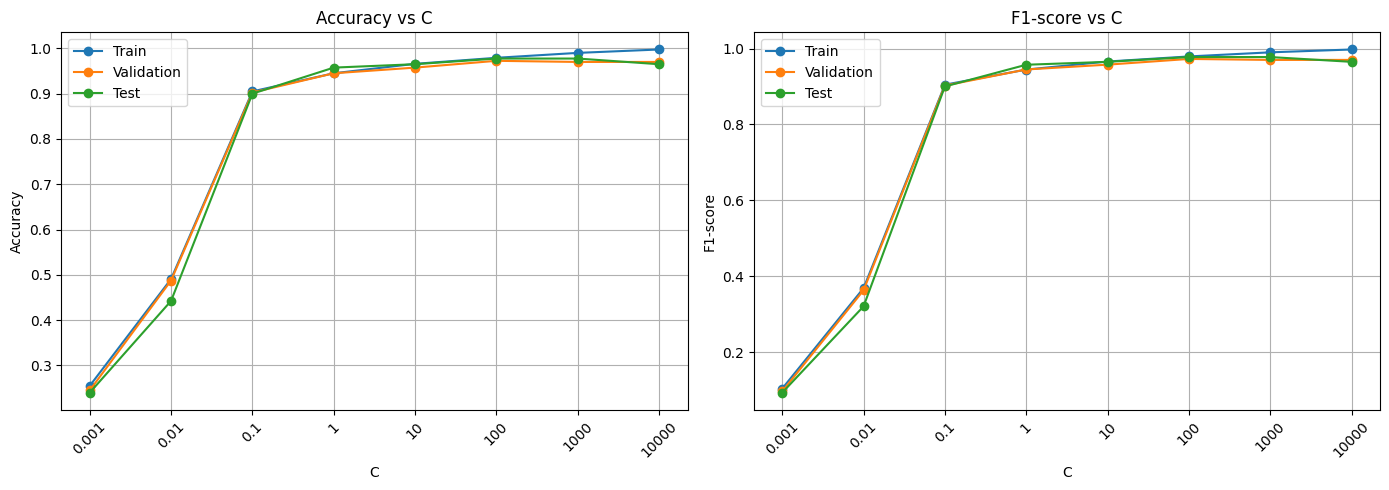

In [9]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_ticks = range(len(C_values))
labels = [str(c) for c in C_values]

for ax, metric, train_scores, val_scores, test_scores, title in [
    (axes[0], 'Accuracy', train_acc, val_acc, test_acc, 'Accuracy vs C'),
    (axes[1], 'F1-score', train_f1,  val_f1,  test_f1,  'F1-score vs C'),
]:
    ax.plot(x_ticks, train_scores, marker='o', label='Train')
    ax.plot(x_ticks, val_scores,   marker='o', label='Validation')
    ax.plot(x_ticks, test_scores,  marker='o', label='Test')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_xlabel('C')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('svm_c_sweep.png', dpi=150)
plt.show()

# Q3

In [10]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
# Filter price_range == 1
df_fp = df[df['price_range'] == 1][['ram', 'int_memory', 'px_width', 'battery_power']].copy()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
# Categorize each feature using 3:4:3 ratio (30% low, 40% medium, 30% high)
def categorize(series):
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val
    low_thresh  = min_val + range_val * 0.3
    high_thresh = min_val + range_val * 0.7
    return series.apply(lambda x: 'low' if x <= low_thresh else ('high' if x >= high_thresh else 'medium'))

for col in ['ram', 'int_memory', 'px_width', 'battery_power']:
    df_fp[col] = categorize(df_fp[col])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
df_fp

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,ram,int_memory,px_width,battery_power
0,high,low,low,low
4,medium,medium,medium,high
5,low,medium,high,high
12,medium,medium,low,high
18,medium,high,low,medium
...,...,...,...,...
1981,medium,low,medium,medium
1984,high,medium,medium,low
1986,medium,high,medium,medium
1988,medium,high,medium,medium


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
# Convert to transaction format (one-hot encoding)
transactions = pd.get_dummies(df_fp[['ram', 'int_memory', 'px_width', 'battery_power']]).astype(bool)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [15]:
transactions

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,ram_high,ram_low,ram_medium,int_memory_high,int_memory_low,int_memory_medium,px_width_high,px_width_low,px_width_medium,battery_power_high,battery_power_low,battery_power_medium
0,True,False,False,False,True,False,False,True,False,False,True,False
4,False,False,True,False,False,True,False,False,True,True,False,False
5,False,True,False,False,False,True,True,False,False,True,False,False
12,False,False,True,False,False,True,False,True,False,True,False,False
18,False,False,True,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1981,False,False,True,False,True,False,False,False,True,False,False,True
1984,True,False,False,False,False,True,False,False,True,False,True,False
1986,False,False,True,True,False,False,False,False,True,False,False,True
1988,False,False,True,True,False,False,False,False,True,False,False,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## (a): Frequent patterns with support >= 0.3 ──

In [14]:
freq_items = fpgrowth(transactions, min_support=0.3, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print("=== Frequent Patterns (support >= 0.3) ===")
print(freq_items.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Frequent Patterns (support >= 0.3) ===
 support                           itemsets
   0.682                       (ram_medium)
   0.416                  (px_width_medium)
   0.414             (battery_power_medium)
   0.412                (int_memory_medium)
   0.318 (battery_power_medium, ram_medium)
   0.316                   (int_memory_low)
   0.308                (battery_power_low)
   0.306      (ram_medium, px_width_medium)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## (b): Association rules support>=0.3, confidence>=0.4, lift>=0.8 ──

In [15]:
rules = association_rules(freq_items, metric='lift', min_threshold=0.8)
rules = rules[(rules['support'] >= 0.3) & (rules['confidence'] >= 0.4)]
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules.sort_values('lift', ascending=False)
print("\n=== Association Rules ===")
print(rules.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Association Rules ===
           antecedents            consequents  support  confidence     lift
(battery_power_medium)           (ram_medium)    0.318    0.768116 1.126270
          (ram_medium) (battery_power_medium)    0.318    0.466276 1.126270
          (ram_medium)      (px_width_medium)    0.306    0.448680 1.078559
     (px_width_medium)           (ram_medium)    0.306    0.735577 1.078559


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Q4

## (a): Standardize

In [16]:
df_pca = pd.read_csv('mobile_price.csv')
X = df_pca.drop('price_range', axis=1).values
y = df_pca['price_range'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## (b): PCA → 2D scatterplot

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

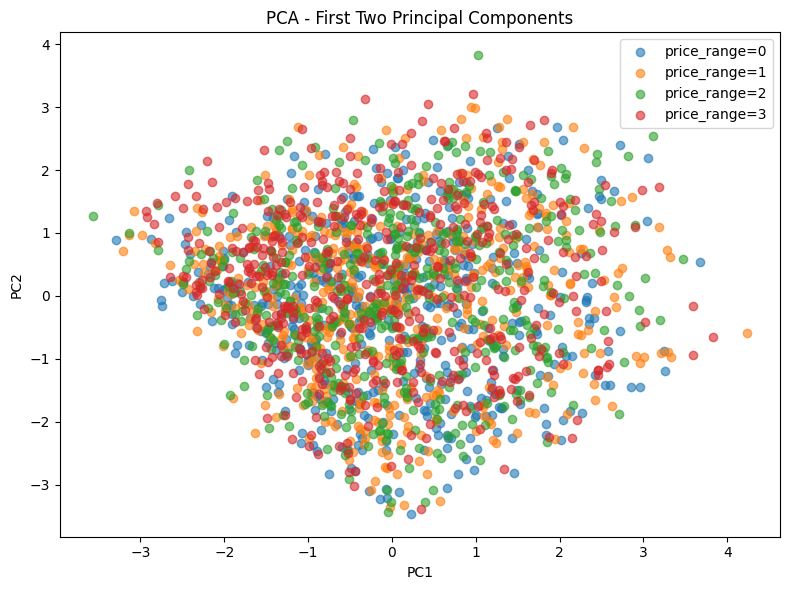

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for label in sorted(np.unique(y)):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'price_range={label}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - First Two Principal Components')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()

## (c): K-Means on all features

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

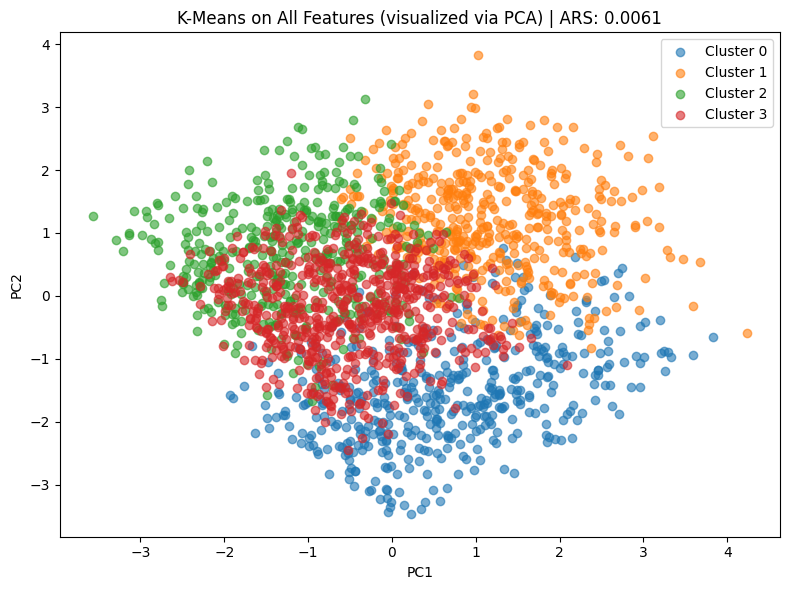

Adjusted Rand Score (all features): 0.0061


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
kmeans_full = KMeans(n_clusters=4, random_state=42)
labels_full = kmeans_full.fit_predict(X_scaled)
ars_full = adjusted_rand_score(y, labels_full)

plt.figure(figsize=(8, 6))
for label in sorted(np.unique(labels_full)):
    mask = labels_full == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {label}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means on All Features (visualized via PCA) | ARS: {ars_full:.4f}')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Adjusted Rand Score (all features): {ars_full:.4f}")

## (d): K-Means on 2D PCA features

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

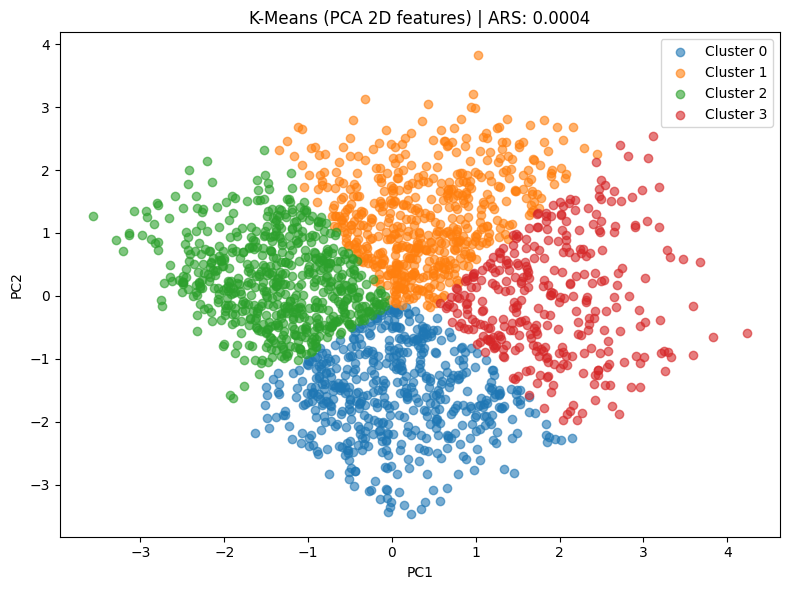

Adjusted Rand Score (PCA 2D): 0.0004


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
kmeans_pca = KMeans(n_clusters=4, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)
ars_pca = adjusted_rand_score(y, labels_pca)

plt.figure(figsize=(8, 6))
for label in sorted(np.unique(labels_pca)):
    mask = labels_pca == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {label}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (PCA 2D features) | ARS: {ars_pca:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150)
plt.show()
print(f"Adjusted Rand Score (PCA 2D): {ars_pca:.4f}")

# Q5

## **Class-Specific ARM Feature Weighting**

The core idea is that instead of mining patterns from the entire dataset, we mine patterns separately for each price class (0, 1, 2, 3), then use those patterns to decide which features matter most.

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score, precision_score, recall_score, f1_score
from mlxtend.frequent_patterns import fpgrowth
from scipy.stats import mode

seeds = [0, 10, 42, 100, 999]

# ── Load & standardize ──
df = pd.read_csv('mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range'].values
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Step 1: Discretize all features ──
def categorize(series):
    min_val, max_val = series.min(), series.max()
    r = max_val - min_val
    return series.apply(lambda x: 'low' if x <= min_val + r*0.3 else ('high' if x >= min_val + r*0.7 else 'medium'))

df_disc = X.apply(categorize)
transactions = pd.get_dummies(df_disc).astype(bool)

# ── Step 2: FP-growth on full dataset ──
freq_items = fpgrowth(transactions, min_support=0.1, use_colnames=True)

# ── Step 3: Compute feature weights from frequent itemsets ──
feature_weights = {f: 0.0 for f in feature_names}

for price_class in [0, 1, 2, 3]:
    df_class = X[y == price_class].apply(categorize)
    trans_class = pd.get_dummies(df_class).astype(bool)
    freq_class = fpgrowth(trans_class, min_support=0.3, use_colnames=True)

    for _, row in freq_class.iterrows():
        for item in row['itemsets']:
            feat = item.rsplit('_', 1)[0]
            if feat in feature_weights:
                # Weight by support * uniqueness to this class
                feature_weights[feat] += row['support']

# Normalize weights to [1, 2] so no feature is zeroed out
weights = np.array([feature_weights[f] for f in feature_names])
weights = 1 + (weights - weights.min()) / (weights.max() - weights.min())
print("Feature weights (top 5):")
for f, w in sorted(zip(feature_names, weights), key=lambda x: -x[1])[:5]:
    print(f"  {f}: {w:.4f}")

# ── Step 4: Apply weights ──
X_weighted = X_scaled * weights

# ── Helper: map cluster labels to true labels ──
def cluster_to_labels(cluster_labels, true_labels, n_clusters=4):
    mapped = np.zeros_like(cluster_labels)
    for c in range(n_clusters):
        mask = cluster_labels == c
        if mask.sum() > 0:
            mapped[mask] = mode(true_labels[mask], keepdims=True).mode[0]
    return mapped

# ── Step 5: Evaluate both methods over multiple seeds ──
def evaluate(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ars':       adjusted_rand_score(y_true, y_pred),
    }

orig_scores = []
weighted_scores = []

for seed in seeds:
    # Original K-Means
    km_orig = KMeans(n_clusters=4, random_state=seed)
    cl_orig = km_orig.fit_predict(X_scaled)
    orig_scores.append(evaluate(y, cluster_to_labels(cl_orig, y)))

    # ARM-weighted K-Means
    km_weighted = KMeans(n_clusters=4, random_state=seed)
    cl_weighted = km_weighted.fit_predict(X_weighted)
    weighted_scores.append(evaluate(y, cluster_to_labels(cl_weighted, y)))

# ── Print average results ──
metrics = ['accuracy', 'precision', 'recall', 'f1', 'ars']
print(f"\n{'Metric':<12} {'Original K-Means':>18} {'ARM-Weighted K-Means':>22}")
print("-" * 55)
for m in metrics:
    orig_avg    = np.mean([s[m] for s in orig_scores])
    weighted_avg = np.mean([s[m] for s in weighted_scores])
    print(f"{m:<12} {orig_avg:>18.4f} {weighted_avg:>22.4f}")

串流輸出內容已截斷至最後 5000 行。
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/p

Feature weights (top 5):
  three_g: 2.0000
  fc: 1.6647
  ram: 1.4901
  four_g: 1.2762
  wifi: 1.2509


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Metric         Original K-Means   ARM-Weighted K-Means
-------------------------------------------------------
accuracy                 0.2911                 0.3405
precision                0.2218                 0.2566
recall                   0.2911                 0.3405
f1                       0.2403                 0.2801
ars                      0.0043                 0.0533


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## **ARM-guided centroid initialization + Feature weighting**

The same per-class ARM patterns determine the best feature profile for each class, which is mapped back to scaled space to construct informed initial centroids instead of random ones

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score, precision_score, recall_score, f1_score
from mlxtend.frequent_patterns import fpgrowth
from scipy.stats import mode

seeds = [0, 10, 42, 100, 999]

# ── Load & standardize ──
df = pd.read_csv('mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range'].values
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Step 1: Discretize all features ──
def categorize(series):
    min_val, max_val = series.min(), series.max()
    r = max_val - min_val
    return series.apply(lambda x: 'low' if x <= min_val + r*0.3 else ('high' if x >= min_val + r*0.7 else 'medium'))

df_disc = X.apply(categorize)
transactions = pd.get_dummies(df_disc).astype(bool)

# ── Step 2: FP-growth on full dataset ──
freq_items = fpgrowth(transactions, min_support=0.1, use_colnames=True)

# ── Step 3: Compute feature weights from frequent itemsets ──
feature_weights = {f: 0.0 for f in feature_names}

for price_class in [0, 1, 2, 3]:
    df_class = X[y == price_class].apply(categorize)
    trans_class = pd.get_dummies(df_class).astype(bool)
    freq_class = fpgrowth(trans_class, min_support=0.3, use_colnames=True)

    for _, row in freq_class.iterrows():
        for item in row['itemsets']:
            feat = item.rsplit('_', 1)[0]
            if feat in feature_weights:
                # Weight by support * uniqueness to this class
                feature_weights[feat] += row['support']

# Normalize weights to [1, 2] so no feature is zeroed out
weights = np.array([feature_weights[f] for f in feature_names])
weights = 1 + (weights - weights.min()) / (weights.max() - weights.min())
print("Feature weights (top 5):")
for f, w in sorted(zip(feature_names, weights), key=lambda x: -x[1])[:5]:
    print(f"  {f}: {w:.4f}")

# ── Step 4: Apply weights ──
X_weighted = X_scaled * weights

# ── Helper: map cluster labels to true labels ──
def cluster_to_labels(cluster_labels, true_labels, n_clusters=4):
    mapped = np.zeros_like(cluster_labels)
    for c in range(n_clusters):
        mask = cluster_labels == c
        if mask.sum() > 0:
            mapped[mask] = mode(true_labels[mask], keepdims=True).mode[0]
    return mapped

# ── Step 5: Evaluate both methods over multiple seeds ──
def evaluate(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ars':       adjusted_rand_score(y_true, y_pred),
    }

# ── ARM-guided Centroid Initialization Method ──
def get_class_centroid(class_label, X_scaled, y, X_orig, feature_names, min_support=0.3):
    df_class = pd.DataFrame(X_orig.values, columns=feature_names)
    df_class = df_class[y == class_label]

    df_disc = df_class.apply(categorize)
    transactions = pd.get_dummies(df_disc).astype(bool)
    freq_items = fpgrowth(transactions, min_support=min_support, use_colnames=True)

    # Vote on best category per feature from frequent patterns
    feature_votes = {f: {'low': 0, 'medium': 0, 'high': 0} for f in feature_names}
    for _, row in freq_items.iterrows():
        for item in row['itemsets']:
            feat, level = item.rsplit('_', 1)
            if feat in feature_votes:
                feature_votes[feat][level] += row['support']

    best_cat = {f: max(votes, key=votes.get) for f, votes in feature_votes.items()}

    # Build centroid using mean of winning category in scaled space
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
    X_scaled_class = X_scaled_df[y == class_label]
    df_disc_class = df_class.apply(categorize)

    centroid = []
    for f in feature_names:
        mask = df_disc_class[f].values == best_cat[f]
        centroid.append(X_scaled_class[f].values[mask].mean())

    return np.array(centroid)

# Build centroids from ARM patterns
init_centroids = np.array([
    get_class_centroid(c, X_scaled, y, X, feature_names)
    for c in [0, 1, 2, 3]
])

# Evaluate all four methods
orig_scores = []
weighted_scores = []
arm_init_scores = []
combined_scores = []
for seed in seeds:
    # Original K-Means
    km_orig = KMeans(n_clusters=4, random_state=seed)
    cl_orig = km_orig.fit_predict(X_scaled)
    orig_scores.append(evaluate(y, cluster_to_labels(cl_orig, y)))

    # ARM-weighted K-Means
    km_weighted = KMeans(n_clusters=4, random_state=seed)
    cl_weighted = km_weighted.fit_predict(X_weighted)
    weighted_scores.append(evaluate(y, cluster_to_labels(cl_weighted, y)))

    # Centroid Init
    km_arm = KMeans(n_clusters=4, init=init_centroids, n_init=1, random_state=seed)
    cl_arm = km_arm.fit_predict(X_scaled)
    arm_init_scores.append(evaluate(y, cluster_to_labels(cl_arm, y)))

    # ARM-Weighted + ARM-Init
    km_combined = KMeans(n_clusters=4, init=init_centroids, n_init=1, random_state=seed)
    cl_combined = km_combined.fit_predict(X_weighted)  # weighted features + ARM centroids
    combined_scores.append(evaluate(y, cluster_to_labels(cl_combined, y)))

# Print all four methods
metrics = ['accuracy', 'precision', 'recall', 'f1', 'ars']
print(f"\n{'Metric':<12} {'Original':>12} {'ARM-Weight':>12} {'ARM-Init':>12} {'Combined':>12}")
print("-" * 63)
for m in metrics:
    orig_avg     = np.mean([s[m] for s in orig_scores])
    weighted_avg = np.mean([s[m] for s in weighted_scores])
    arm_avg      = np.mean([s[m] for s in arm_init_scores])
    comb_avg     = np.mean([s[m] for s in combined_scores])
    print(f"{m:<12} {orig_avg:>12.4f} {weighted_avg:>12.4f} {arm_avg:>12.4f} {comb_avg:>12.4f}")

串流輸出內容已截斷至最後 5000 行。
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/p

Feature weights (top 5):
  three_g: 2.0000
  fc: 1.6647
  ram: 1.4901
  four_g: 1.2762
  wifi: 1.2509


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Metric           Original   ARM-Weight     ARM-Init     Combined
---------------------------------------------------------------
accuracy           0.2911       0.3405       0.2985       0.4195
precision          0.2218       0.2566       0.2276       0.3105
recall             0.2911       0.3405       0.2985       0.4195
f1                 0.2403       0.2801       0.2458       0.3447
ars                0.0043       0.0533       0.0057       0.1274


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag